# Fund Performance Analytics
This notebook calculates performance metrics (CAGR, Sharpe, Sortino, Alpha, Beta, Drawdown) for 40 Bluestock mutual fund schemes, generates a composite scorecard, and benchmarks the top funds.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# Connect to database
conn = sqlite3.connect('bluestock_mf.db')

# Load data
fact_nav = pd.read_sql('SELECT * FROM fact_nav', conn)
fact_bench = pd.read_sql('SELECT * FROM fact_benchmark_indices', conn)
dim_fund = pd.read_sql('SELECT * FROM dim_fund', conn)
fact_perf = pd.read_sql('SELECT * FROM fact_performance', conn)

# Date conversions
fact_nav['date'] = pd.to_datetime(fact_nav['date'])
fact_bench['date'] = pd.to_datetime(fact_bench['date'])

# Only use original trading days for return calculations to avoid 0% returns from forward filling weekends
fact_nav = fact_nav[fact_nav['is_trading_day'] == 1].sort_values(['amfi_code', 'date'])

print(f"Loaded {len(fact_nav)} trading day NAV records for {fact_nav['amfi_code'].nunique()} funds.")


Loaded 46000 trading day NAV records for 40 funds.


## 1. Daily Returns, Sharpe, and Sortino Ratios
Calculate daily returns, standard deviation, downside deviation, Sharpe Ratio (Rf=6.5%), and Sortino Ratio.

In [2]:
# 1. Daily Returns
fact_nav['daily_return'] = fact_nav.groupby('amfi_code')['nav'].pct_change()
returns = fact_nav.dropna(subset=['daily_return'])

rf_rate = 0.065
rf_daily = rf_rate / 252

metrics = []

for code, group in returns.groupby('amfi_code'):
    ret_array = group['daily_return'].values
    
    # Sharpe Ratio
    mean_ret = ret_array.mean()
    std_ret = ret_array.std()
    sharpe = ((mean_ret - rf_daily) / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan
    
    # Sortino Ratio
    neg_rets = ret_array[ret_array < 0]
    downside_std = neg_rets.std()
    sortino = ((mean_ret - rf_daily) / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan
    
    metrics.append({
        'amfi_code': code,
        'sharpe_ratio_calc': sharpe,
        'sortino_ratio_calc': sortino
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.head())


,amfi_code,sharpe_ratio_calc,sortino_ratio_calc
0,100016,-0.201605,-0.351351
1,100025,-0.567342,-0.942680
2,100033,1.094175,1.830836
3,101206,1.027661,1.801235
4,101207,0.162732,0.276888


## 2. CAGR Calculation (1yr, 3yr, 5yr)
Calculate the compound annual growth rate.

In [3]:
cagr_results = []
latest_date = fact_nav['date'].max()

for code, group in fact_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    if len(group) == 0:
        continue
        
    nav_end = group.iloc[-1]['nav']
    date_end = group.iloc[-1]['date']
    
    cagrs = {'amfi_code': code}
    
    for years in [1, 3, 5]:
        target_date = date_end - pd.DateOffset(years=years)
        # Find closest date on or before target date
        past_data = group[group['date'] <= target_date]
        
        if not past_data.empty:
            nav_start = past_data.iloc[-1]['nav']
            cagrs[f'cagr_{years}yr'] = (nav_end / nav_start) ** (1 / years) - 1
        else:
            cagrs[f'cagr_{years}yr'] = np.nan
            
    cagr_results.append(cagrs)

cagr_df = pd.DataFrame(cagr_results)
metrics_df = metrics_df.merge(cagr_df, on='amfi_code', how='left')
display(metrics_df[['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].head())


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


## 3. Alpha and Beta (vs NIFTY 100)
Run OLS regression against NIFTY 100 benchmark returns.

In [4]:
# Get NIFTY 100 returns
nifty100 = fact_bench[fact_bench['index_name'] == 'NIFTY100'].sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bench_return'])

# Merge with fund returns
alpha_beta_results = []

for code, group in returns.groupby('amfi_code'):
    merged = pd.merge(group[['date', 'daily_return']], nifty100[['date', 'bench_return']], on='date', how='inner')
    if len(merged) > 30: # Need sufficient points
        slope, intercept, r_value, p_value, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
        alpha = intercept * 252
        beta = slope
    else:
        alpha = np.nan
        beta = np.nan
        
    alpha_beta_results.append({
        'amfi_code': code,
        'alpha_calc': alpha,
        'beta_calc': beta
    })

ab_df = pd.DataFrame(alpha_beta_results)
ab_df.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv")

metrics_df = metrics_df.merge(ab_df, on='amfi_code', how='left')


Saved alpha_beta.csv


## 4. Maximum Drawdown
Identify the worst peak-to-trough drop.

In [5]:
dd_results = []

for code, group in fact_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    group['roll_max'] = group['nav'].cummax()
    group['drawdown'] = group['nav'] / group['roll_max'] - 1
    
    worst_idx = group['drawdown'].idxmin()
    max_dd = group.loc[worst_idx, 'drawdown']
    dd_date = group.loc[worst_idx, 'date']
    
    dd_results.append({
        'amfi_code': code,
        'max_drawdown_calc': max_dd,
        'worst_dd_date': dd_date
    })

dd_df = pd.DataFrame(dd_results)
metrics_df = metrics_df.merge(dd_df, on='amfi_code', how='left')


## 5. Fund Scorecard
Composite score (0-100) based on:
- 30% 3yr Return rank
- 25% Sharpe rank
- 20% Alpha rank
- 15% Expense Ratio rank (inverse)
- 10% Max Drawdown rank (inverse)

In [6]:
# Merge expense ratio
score_df = metrics_df.merge(dim_fund[['amfi_code', 'scheme_name', 'expense_ratio_pct']], on='amfi_code', how='left')

# Calculate percentiles (0 to 1 scale)
score_df['rank_3yr'] = score_df['cagr_3yr'].rank(pct=True)
score_df['rank_sharpe'] = score_df['sharpe_ratio_calc'].rank(pct=True)
score_df['rank_alpha'] = score_df['alpha_calc'].rank(pct=True)

# Inverse ranks (lower expense/drawdown is better, meaning higher score)
score_df['rank_expense'] = score_df['expense_ratio_pct'].rank(pct=True, ascending=False)
score_df['rank_dd'] = score_df['max_drawdown_calc'].rank(pct=True) # DD is negative, so higher algebraic value is better (closer to 0)

# Composite Score (0-100)
score_df['composite_score'] = (
    score_df['rank_3yr'].fillna(0) * 30 +
    score_df['rank_sharpe'].fillna(0) * 25 +
    score_df['rank_alpha'].fillna(0) * 20 +
    score_df['rank_expense'].fillna(0) * 15 +
    score_df['rank_dd'].fillna(0) * 10
)

score_df = score_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
score_df['final_rank'] = score_df.index + 1

score_df.to_csv('fund_scorecard.csv', index=False)
print("Saved fund_scorecard.csv")
display(score_df[['final_rank', 'scheme_name', 'composite_score']].head(10))


Saved fund_scorecard.csv


,final_rank,scheme_name,composite_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,86.2500
1,2,ICICI Pru Midcap Fund - Regular - Growth,82.2500
2,3,Kotak Flexicap Fund - Regular - Growth,82.0000
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500
4,5,ICICI Pru Bluechip Fund - Direct - Growth,80.0000
5,6,Axis Midcap Fund - Regular - Growth,77.0000
6,7,SBI Bluechip Fund - Regular Plan - Growth,74.8125
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875
8,9,ABSL Frontline Equity Fund - Regular - Growth,68.1875
9,10,SBI Small Cap Fund - Regular Plan - Growth,67.3750


## 6. Benchmark Comparison (Top 5 Funds vs NIFTY 50 & NIFTY 100)
Plot the top 5 funds from the scorecard over the last 3 years and calculate tracking error.

Saved benchmark_comparison_chart.png


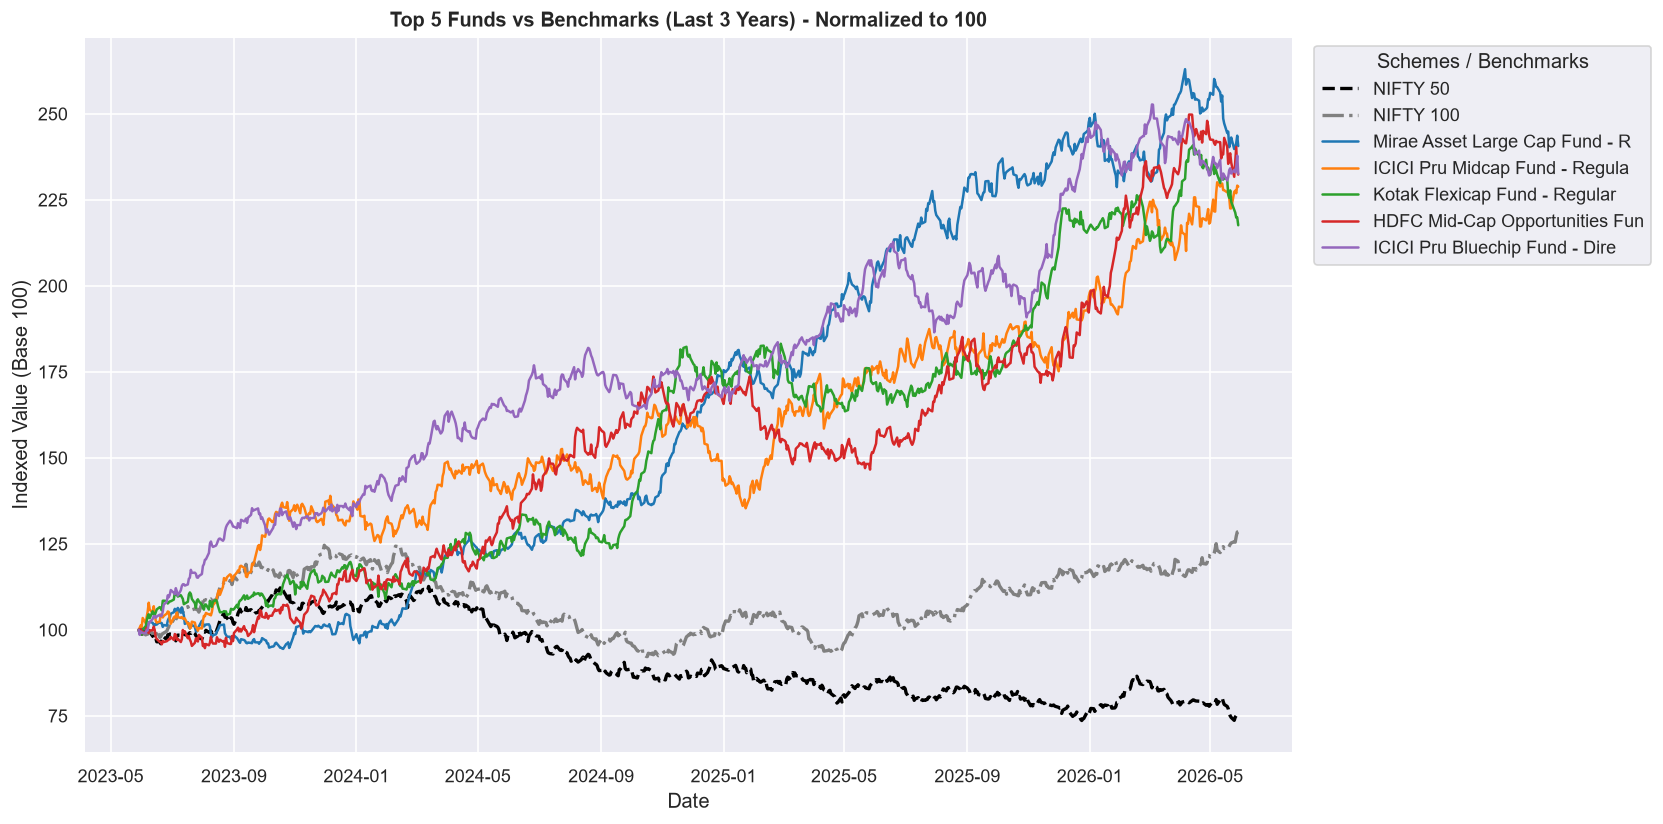

Tracking Error (vs NIFTY 100) over 3 years:
Mirae Asset Large Cap Fund - R: TE = 18.80%
ICICI Pru Midcap Fund - Regula: TE = 23.27%
Kotak Flexicap Fund - Regular : TE = 20.65%
HDFC Mid-Cap Opportunities Fun: TE = 22.50%
ICICI Pru Bluechip Fund - Dire: TE = 18.73%


In [7]:
top5_codes = score_df.head(5)['amfi_code'].tolist()

# Last 3 years
end_date = fact_nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

# Filter NAV data
plot_nav = fact_nav[(fact_nav['amfi_code'].isin(top5_codes)) & (fact_nav['date'] >= start_date)]

# Filter benchmarks
nifty50 = fact_bench[(fact_bench['index_name'] == 'NIFTY50') & (fact_bench['date'] >= start_date)].sort_values('date')
nifty100 = fact_bench[(fact_bench['index_name'] == 'NIFTY100') & (fact_bench['date'] >= start_date)].sort_values('date')

# Normalize to 100
nifty50['norm_val'] = nifty50['close_value'] / nifty50['close_value'].iloc[0] * 100
nifty100['norm_val'] = nifty100['close_value'] / nifty100['close_value'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))

# Plot benchmarks
ax.plot(nifty50['date'], nifty50['norm_val'], label='NIFTY 50', color='black', linewidth=2, linestyle='--')
ax.plot(nifty100['date'], nifty100['norm_val'], label='NIFTY 100', color='gray', linewidth=2, linestyle='-.')

pal = sns.color_palette('tab10', 5)

te_results = []
# Plot funds and calculate tracking error vs NIFTY 100
nifty100_rets = nifty100.set_index('date')['close_value'].pct_change().dropna()

for i, code in enumerate(top5_codes):
    grp = plot_nav[plot_nav['amfi_code'] == code].sort_values('date')
    if not grp.empty:
        norm_nav = grp['nav'] / grp['nav'].iloc[0] * 100
        name = score_df[score_df['amfi_code'] == code]['scheme_name'].iloc[0][:30]
        ax.plot(grp['date'], norm_nav, label=name, color=pal[i], linewidth=1.5)
        
        # Tracking Error vs NIFTY 100
        fund_rets = grp.set_index('date')['nav'].pct_change().dropna()
        merged = pd.merge(fund_rets, nifty100_rets, left_index=True, right_index=True, how='inner')
        active_returns = merged['nav'] - merged['close_value']
        tracking_error = active_returns.std() * np.sqrt(252)
        te_results.append(f"{name}: TE = {tracking_error:.2%}")

ax.set_title('Top 5 Funds vs Benchmarks (Last 3 Years) - Normalized to 100', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Value (Base 100)')
ax.legend(title='Schemes / Benchmarks', loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('benchmark_comparison_chart.png')
print("Saved benchmark_comparison_chart.png")
plt.show()

print("Tracking Error (vs NIFTY 100) over 3 years:")
for t in te_results:
    print(t)


In [8]:
conn.close()
print("Performance Analytics Complete.")

Performance Analytics Complete.
